In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [19]:
img = cv2.imread('cat.png', 0)

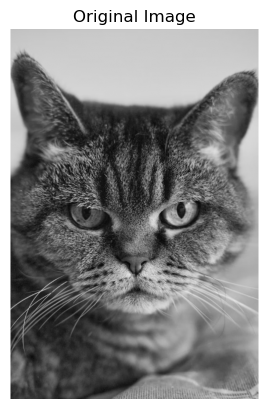

In [27]:
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [28]:
# compute the 1D FFT of the image
fft = np.fft.fft2(img)
fft_shifted = np.fft.fftshift(fft)

In [29]:
# magnitude spectrum
magnitude_spectrum = 20 * np.log(np.abs(fft_shifted))

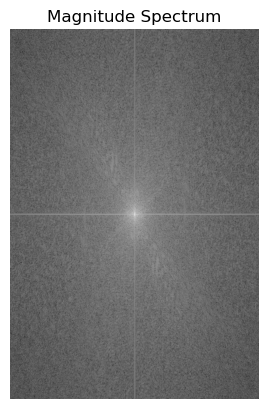

In [30]:
# plot the magnitude spectrum
plt.title('Magnitude Spectrum')
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')
plt.show()

In [31]:
# Filtering in the frequency domain
# create a ideal low-pass filter
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
D0 = 30  # cutoff frequency
u, v = np.meshgrid(np.arange(cols), np.arange(rows))
D = np.sqrt((u - ccol)**2 + (v - crow)**2)
H = (D <= D0).astype(int)

/tmp/ipykernel_7880/2222052195.py:3: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum_filtered = 20 * np.log(np.abs(fft_filtered))


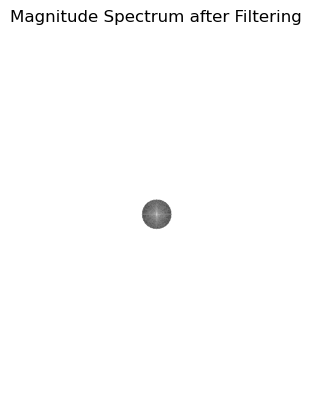

In [32]:
# plot after filtering
fft_filtered = fft_shifted * H
magnitude_spectrum_filtered = 20 * np.log(np.abs(fft_filtered))
plt.title('Magnitude Spectrum after Filtering')
plt.imshow(magnitude_spectrum_filtered, cmap='gray')
plt.axis('off')
plt.show()

/tmp/ipykernel_7880/1978999272.py:5: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum_filtered_high = 20 * np.log(np.abs(fft_filtered_high))


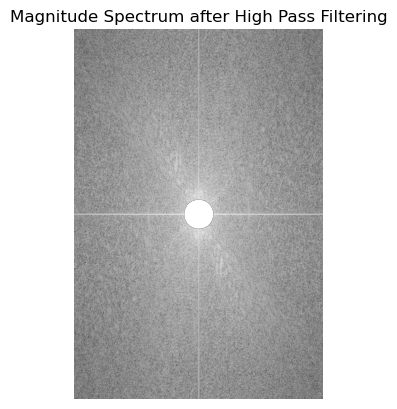

In [33]:
# High pass filter
H_high = (D > D0).astype(int)
# plot after high pass filtering
fft_filtered_high = fft_shifted * H_high
magnitude_spectrum_filtered_high = 20 * np.log(np.abs(fft_filtered_high))
plt.title('Magnitude Spectrum after High Pass Filtering')
plt.imshow(magnitude_spectrum_filtered_high, cmap='gray')
plt.axis('off')
plt.show()